In [27]:
import pandas as pd
import numpy as np

In [28]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "processed_timeseries_table_timeseries_table " + "(10)" + ".csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "lsobieski/processed-thermostat-data",
  file_path,
)

df.head()

,Timestamp,Temperature,Setpoint,FanState,OutputState,RunningMode,CumulativeRuntime,CumulativeCost,Year,Month,Day,RunningMode_off,Outdoor_Temperature,outsideMinTemp,outsideMaxTemp,outsideHumidity
0,2025-02-13 12:32:53,24.15,0.0,0.0,0.0,0.0,NaN,NaN,2025.0,2.0,13.0,1.0,0.052000,-1.44,0.58,71.0
1,2025-02-13 12:33:29,23.86,0.0,0.0,1.0,0.0,NaN,NaN,2025.0,2.0,13.0,1.0,0.064000,-1.44,0.58,71.0
2,2025-02-13 12:33:35,NaN,0.0,0.0,1.0,0.0,NaN,NaN,2025.0,2.0,13.0,1.0,0.066000,-1.44,0.58,71.0
3,2025-02-13 12:34:04,23.54,0.0,0.0,1.0,0.0,NaN,NaN,2025.0,2.0,13.0,1.0,0.075667,-1.44,0.58,71.0
4,2025-02-13 12:34:40,NaN,0.0,0.0,1.0,0.0,NaN,NaN,2025.0,2.0,13.0,1.0,0.087667,-1.44,0.58,71.0


In [29]:
df["CumulativeRuntime"] = df["CumulativeRuntime"].ffill()

In [30]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Date'] = df['Timestamp'].dt.date

In [31]:
df["CumulativeRuntime"].dtype

dtype('float64')

In [32]:
df['CumulativeRuntime'] = (
    pd.to_timedelta(df['CumulativeRuntime'], errors='coerce')
      .dt.total_seconds()
)

In [33]:
daily_data = df.groupby('Date').agg(
    #should have a check for if running from before midnight to next day
    runtime_start=('CumulativeRuntime', 'first'),
    runtime_end=('CumulativeRuntime', 'last'),

    avg_setpoint=('Setpoint', 'mean'),
    #fix this through interpolation later but for now ok
    temp_at_midnight=('Temperature', 'first'),
    #
    outdoor_temp_at_midnight=('Outdoor_Temperature', 'first'),
    outdoor_humidity_at_midnight=('outsideHumidity', 'first'),
)

daily_data["daily_runtime"] = daily_data["runtime_end"] - daily_data["runtime_start"]

daily_data.head()
    

,runtime_start,runtime_end,avg_setpoint,temp_at_midnight,outdoor_temp_at_midnight,outdoor_humidity_at_midnight,daily_runtime
Date,,,,,,,
2025-02-13,NaN,NaN,21.961415,24.15,0.052000,71.0,NaN
2025-02-14,NaN,NaN,24.440000,22.50,-5.524561,89.0,NaN
2025-02-15,NaN,NaN,24.440000,20.69,7.042472,63.0,NaN
2025-02-16,NaN,NaN,24.440000,20.69,12.536759,97.0,NaN
2025-02-17,NaN,NaN,23.567797,20.51,-2.420000,70.0,NaN


In [34]:
daily_data.isnull().sum()

runtime_start                   340
runtime_end                     340
avg_setpoint                      0
temp_at_midnight                104
outdoor_temp_at_midnight          0
outdoor_humidity_at_midnight      0
daily_runtime                   340
dtype: int64

In [35]:
daily_data.shape

(340, 7)

In [36]:
daily_data = daily_data.drop(columns = ["runtime_start", "runtime_end"])


In [37]:
daily_data['day_gap'] = daily_data.index.to_series().diff().dt.days
gaps = daily_data[daily_data['day_gap'] != 1]
gaps

,avg_setpoint,temp_at_midnight,outdoor_temp_at_midnight,outdoor_humidity_at_midnight,daily_runtime,day_gap
Date,,,,,,
2025-02-13,21.961415,24.15,0.052000,71.0,NaN,NaN
2026-01-08,21.110000,NaN,10.926889,97.0,NaN,28.0
2026-02-18,21.110000,NaN,-4.210000,90.0,NaN,14.0


In [38]:
daily_data.index = pd.to_datetime(daily_data.index)
daily_data = daily_data.loc[:'2026-01-07']
daily_data.shape

(302, 6)

In [39]:
target = 'daily_runtime'

daily_data['avg_setpoint_lagged'] = daily_data['avg_setpoint'].shift(1)

In [40]:
daily_data.isnull().sum()

avg_setpoint                      0
temp_at_midnight                 66
outdoor_temp_at_midnight          0
outdoor_humidity_at_midnight      0
daily_runtime                   302
day_gap                           1
avg_setpoint_lagged               1
dtype: int64

In [17]:
#drop places that are missing a lagged setpoint (position 1)
daily_data = daily_data.dropna()

In [18]:
#rolling window params
window_size = 21

In [25]:
# need to add weather data here
X = daily_data[['avg_setpoint_lagged', 'temp_at_midnight', 'outdoor_temp_at_midnight', 'outdoor_humidity_at_midnight']].values
y = daily_data['daily_runtime'].values
dates = daily_data.index

windows = []

for end in range(window_size, len(daily_data) - 1 + 1):
    start = end - window_size

    print(end)
    X_train = X[start:end]
    y_train = y[start:end]
    
    X_test = X[end:end + 1]
    y_test = y[end:end + 1]
    
    test_date = dates[end]
    
    windows.append((X_train, y_train, X_test, y_test, test_date))

In [24]:
from sklearn.linear_model import LinearRegression

predictions = []

for X_train, y_train, X_test, y_test, test_date in windows:
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)[0]
    
    predictions.append({
        'Date': test_date,
        'y_true': y_test[0],
        'y_pred': y_pred
    })
    
print(windows)
pred_df = pd.DataFrame(predictions).set_index('Date')

[]


KeyError: "None of ['Date'] are in the columns"

In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(pred_df['y_true'], pred_df['y_pred'])
print("MSE:",mse) 

print("RMSE:", np.sqrt(mse))

<Axes: title={'center': 'Rolling Window Prediction'}, xlabel='Date'>

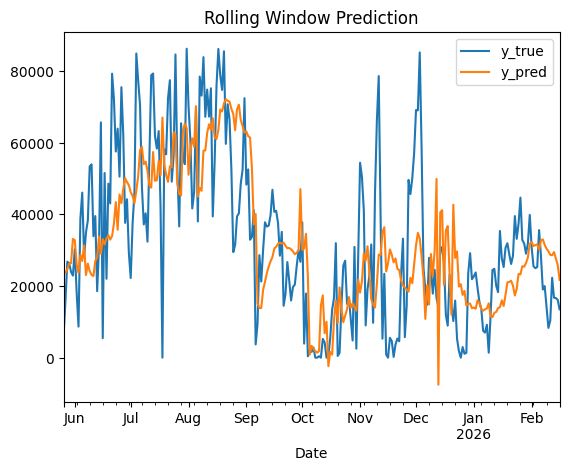

In [31]:
pred_df[['y_true', 'y_pred']].plot(title='Rolling Window Prediction')

In [ ]:
y_true = pred_df["y_true"].to_numpy()
y_pred = pred_df["y_pred"].to_numpy()

In [ ]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    explained_variance_score,
)

In [ ]:
mae = mean_absolute_error(y_true, y_pred)
medae = np.median(np.abs(y_true - y_pred))
maxae = np.max(np.abs(y_true - y_pred))

In [ ]:
def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred) + eps)
    return 100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / denom)

def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return 100.0 * np.mean(np.abs((y_true - y_pred) / (y_true + eps)))

In [ ]:
# Relative / % metrics
mape_val = mape(y_true, y_pred)
smape_val = smape(y_true, y_pred)

In [ ]:
r2 = r2_score(y_true, y_pred)
evs = explained_variance_score(y_true, y_pred)

In [ ]:
metrics = pd.Series({
    "MSE": mse,
    "RMSE": rmse,
    "MAE": mae,
    "MedianAE": medae,
    "MaxAE": maxae,
    "MAPE (%)": mape_val,
    "sMAPE (%)": smape_val,
    "R2": r2,
    "ExplainedVariance": evs,
})

In [ ]:
print("\n=== Model Evaluation (Rolling Predictions) ===")
display(metrics.to_frame("value"))